In [ ]:
# PROJECT_HEART_DISEASE_COMPLETE)

In [ ]:
# 1. Data Analysis:
a. Import the dataset
b. Get information about the dataset (mean, max, min, quartiles etc.) 
c. Find the correlation between all fields

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. Import the dataset
df = pd.read_csv('dataset.csv')   

# 2. Get basic info
print("\n--- Dataset Info ---")
print(df.info())

print("\n--- First 5 Rows ---")
print(df.head())

# 3. Statistical summary (mean, max, min, quartiles etc.)
print("\n--- Statistical Summary ---")
print(df.describe(include="all"))

# 4. Correlation matrix
correlation = df.corr(numeric_only=True)

# 5. Top 5 features most correlated with target
target_corr = correlation["target"].drop("target")
top_features = target_corr.abs().sort_values(ascending=False).head(5)

print("\n--- Top 5 Features Most Correlated with Target ---")
print(top_features)

# fmt=".2f" means:---Format the numbers inside the heatmap to 2 decimal places (floating point).



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

--- First 5 Rows ---
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37  

In [ ]:
2. Data Visualization:
a. Visualize the number of patients having a heart disease and not having
a heart disease
b. Visualize the age and whether a patient has disease or not 
c. Visualize correlation between all features using a heat map

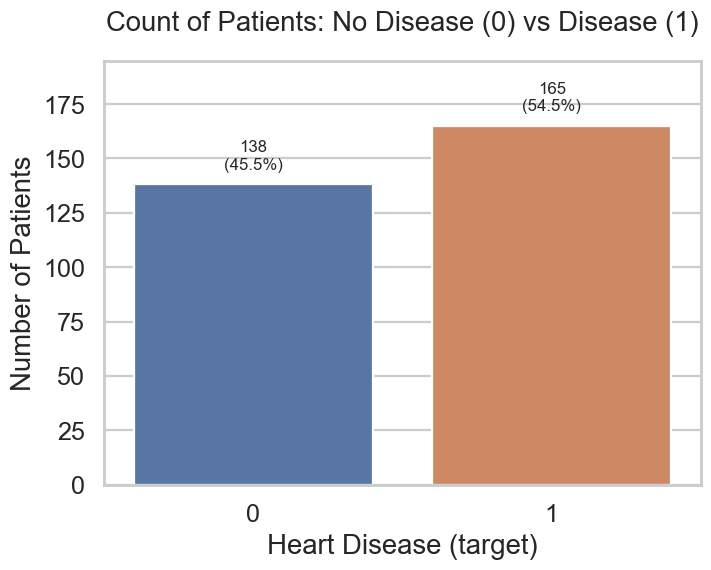

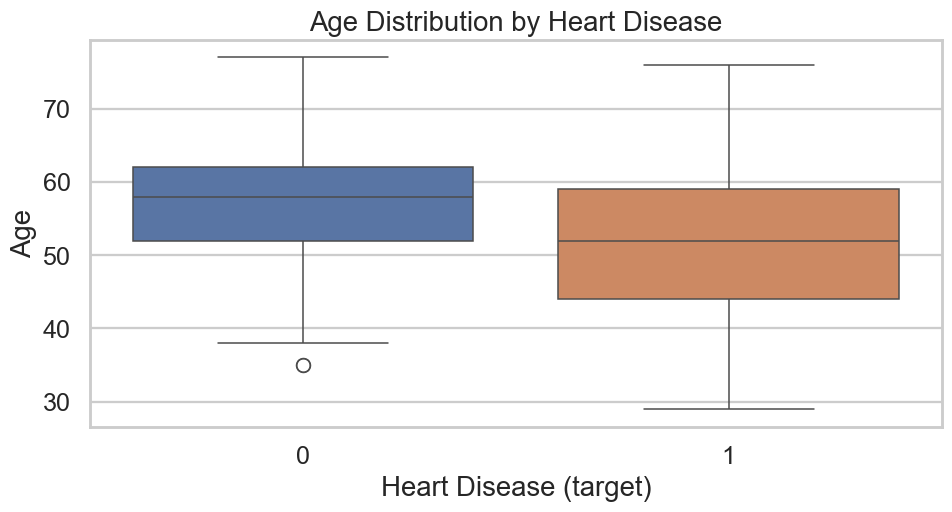

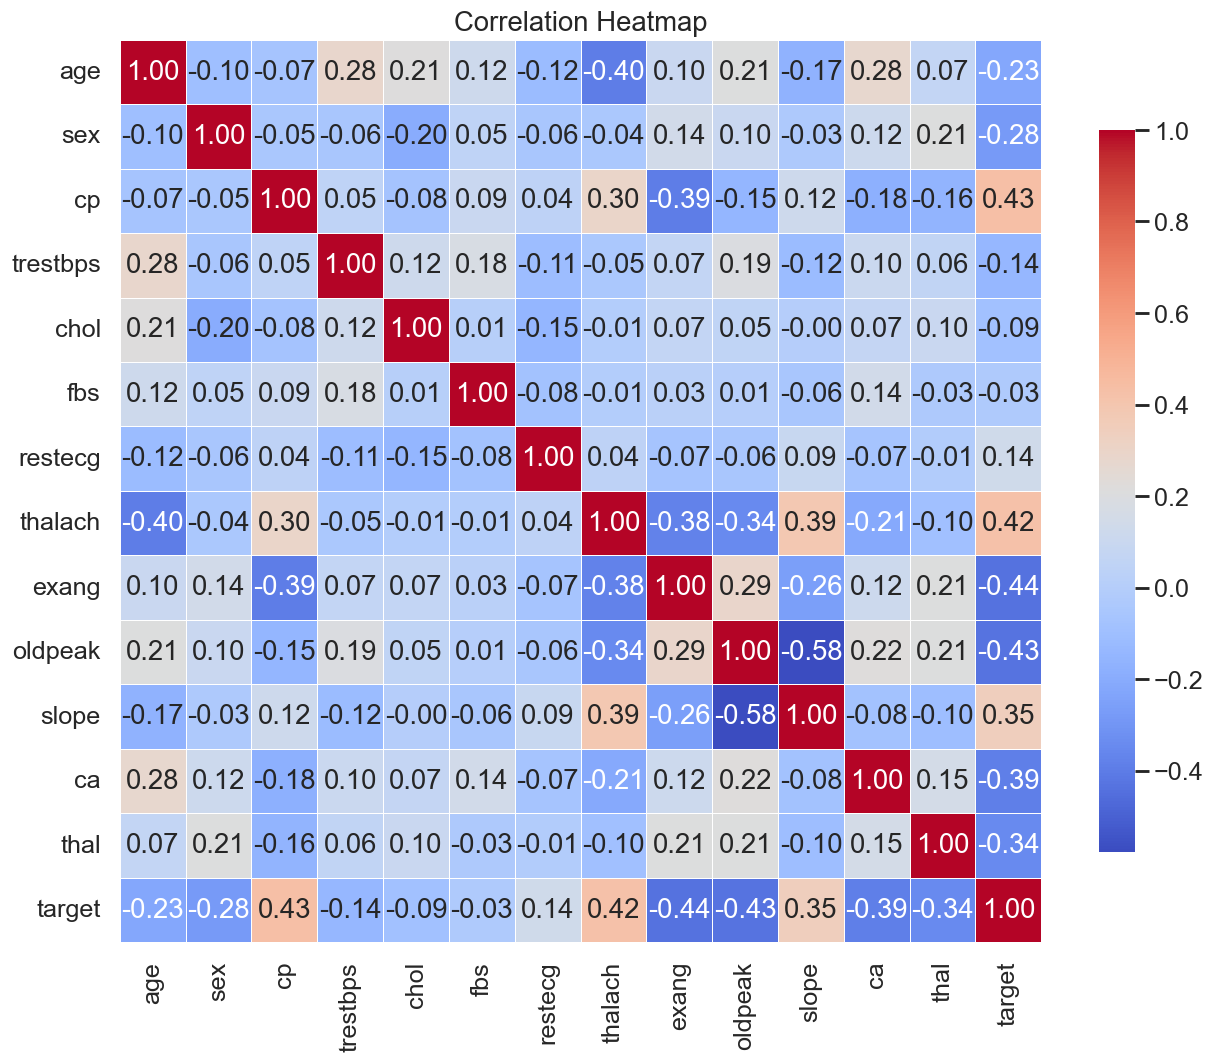

In [2]:
  
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

# Ensure the expected columns exist
if "target" not in df.columns or "age" not in df.columns:
    raise ValueError("Dataset must contain 'target' and 'age' columns")

# Convert target to categorical (optional)
df["target"] = df["target"].astype(int)

# ---- (a) Visualize number of patients having a heart disease and not ----

# ---- (a) Visualize number of patients having a heart disease and not ----

plt.figure(figsize=(7,5))

order = [0, 1]  # 0 = no disease, 1 = disease

ax = sns.countplot(
    x="target",
    data=df,
    order=order,
    hue="target",
    palette=["#4c72b0", "#dd8452"],
    legend=False
)

ax.set_title("Count of Patients: No Disease (0) vs Disease (1)")
ax.set_xlabel("Heart Disease (target)")
ax.set_ylabel("Number of Patients")

# Annotate with counts and percentages
# Annotate with counts and percentages
total = len(df)

for p in ax.patches:
    height = p.get_height()
    perc = 100.0 * height / total

    ax.annotate(
        f"{height:.0f}\n({perc:.1f}%)",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=11,
        xytext=(0, 8),
        textcoords="offset points"
    )

# Create extra space above the highest bar
ax.set_ylim(0, max(p.get_height() for p in ax.patches) * 1.18)

# Move title slightly upward
ax.set_title(
    "Count of Patients: No Disease (0) vs Disease (1)",
    pad=20
)

# ---- (b) Visualize age and whether a patient has disease or not ----

plt.figure(figsize=(9,5))

ax = sns.boxplot(
    x="target",
    y="age",
    data=df,
    order=order,
    hue="target",
    palette=["#4c72b0", "#dd8452"],
    legend=False
)

ax.set_title("Age Distribution by Heart Disease")
ax.set_xlabel("Heart Disease (target)")
ax.set_ylabel("Age")

plt.tight_layout()
plt.show()


# ---- (c) Correlation between all numeric features (heatmap) ----

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=False,
            cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



In [ ]:
# 3. Logistic Regression:
a. Build a simple logistic regression model:
i. Divide the dataset in 70:30 ratio
ii. Build the model on train set and predict the values on test set 
iii. Build the confusion matrix and get the accuracy score

In [3]:
# Logistic Regression Model for Heart Disease Dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [4]:
# 1. Load dataset
df = pd.read_csv('dataset.csv')  
print (df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [5]:
# 2. Define features (X) and target (y)
X = df.drop("target", axis=1)  
y = df["target"]            

In [6]:
# 3. Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [7]:
# 4. Build Logistic Regression model
lr = LogisticRegression(max_iter=1000)   
lr.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [9]:
# 5. Predict on test set
y_pred = lr.predict(X_test)
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0])

In [10]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)

Confusion Matrix: [[28 13]
 [10 40]]


In [11]:
# 7. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.2f}%".format(accuracy * 100))

Accuracy Score: 74.73%


In [ ]:
# 4. Decision Tree:
a. Build a decision tree model:
i. Divide the dataset in 70:30 ratio
ii. Build the model on train set and predict the values on test set 
iii. Build the confusion matrix and calculate the accuracy
iv. Visualize the decision tree using the Graphviz package

In [12]:
# Decision Tree Classifier for Heart Disease Dataset

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import graphviz


In [13]:
# 1. Load dataset
df = pd.read_csv('dataset.csv')  
print (df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [14]:
# 2. Define features (X) and target (y)
X = df.drop("target", axis=1)  
y = df["target"]                

In [15]:
# 3. Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [16]:
# 4. Build Decision Tree model
dt = DecisionTreeClassifier(random_state=42, max_depth=4) 
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
# 5. Predict on test set
y_pred = dt.predict(X_test)
y_pred 

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0])

In [18]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)


Confusion Matrix: [[30 11]
 [ 9 41]]


In [19]:
# 7. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.2f}%".format(accuracy * 100))

Accuracy Score: 78.02%


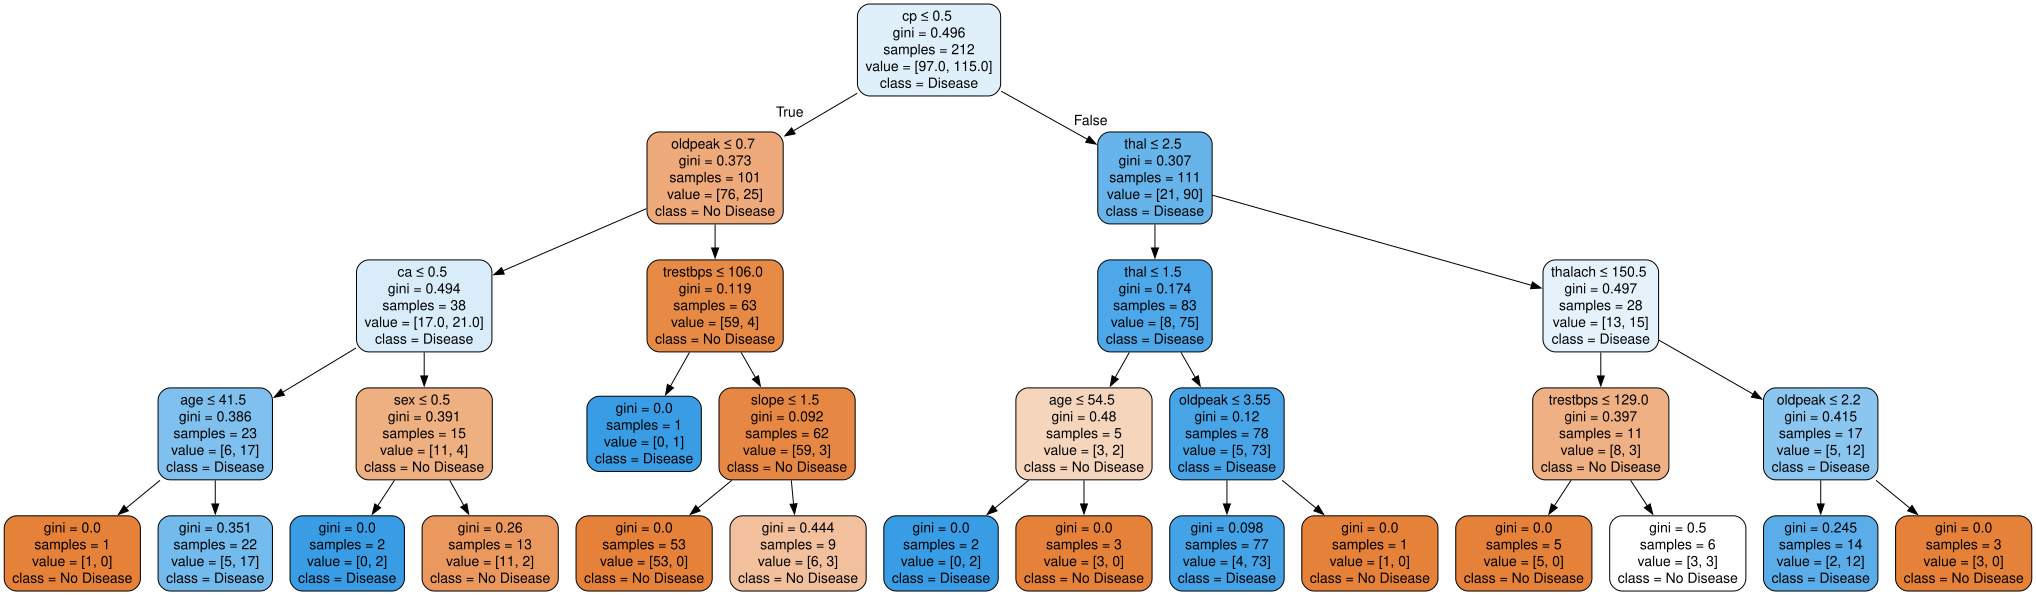

In [21]:
# 9. Visualize Decision Tree using Graphviz
dot_data = export_graphviz(
    dt,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.format = 'png'
graph      


In [ ]:
# 5. Random Forest:
a. Build a Random Forest model:
i. Divide the dataset in 70:30 ratio
ii. Build the model on train set and predict the values on test set 
iii. Build the confusion matrix and calculate the accuracy
iv. Visualize the model using the Graphviz package

In [22]:
# Random Forest Classifier for Heart Disease Dataset
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score 



In [23]:
# 1. Load dataset
df = pd.read_csv('dataset.csv')  
print (df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [24]:
# 2. Define features (X) and target (y)
X = df.drop("target", axis=1)
y = df["target"]


In [25]:
# 3. Split dataset (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [26]:
# 4. Build Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42) 
rf.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
# 5. Predict on test set
y_pred = rf.predict(X_test)
y_pred


array([1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0])

In [28]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:", cm)


Confusion Matrix: [[30 11]
 [ 8 42]]


In [29]:
# 7. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score: {:.2f}%".format(accuracy * 100))


Accuracy Score: 79.12%


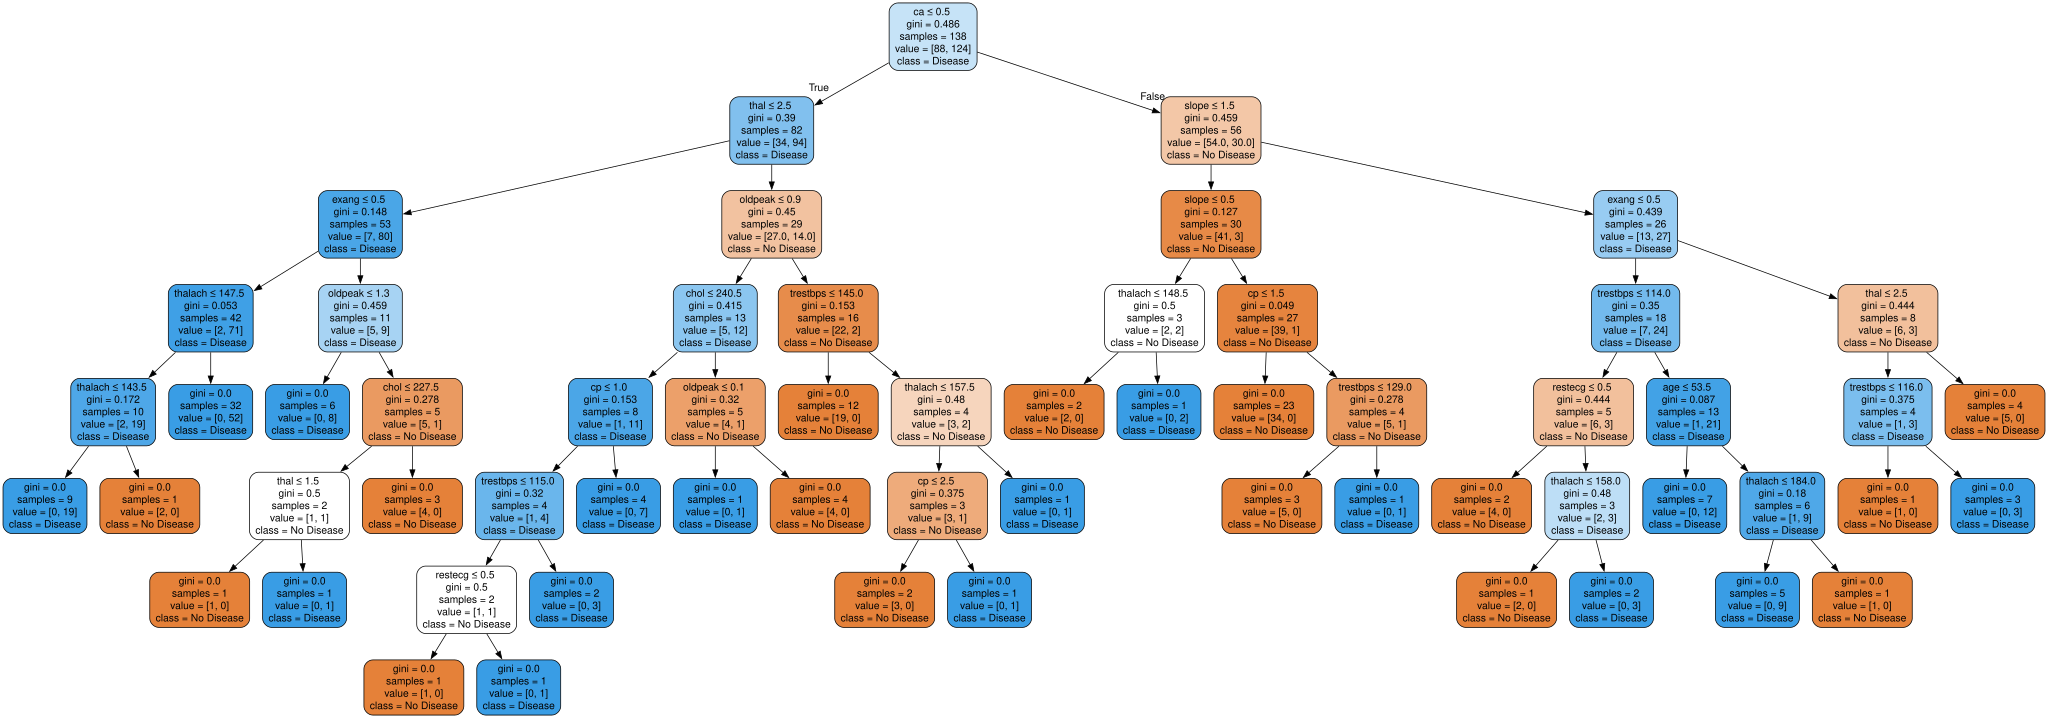

In [30]:
from sklearn.tree import export_graphviz
import graphviz

# Pick the first tree from the Random Forest
estimator = rf.estimators_[0]

dot_data = export_graphviz(
    estimator,
    out_file=None,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True, rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

In [ ]:
# 6. Select the best model
a. Print the confusion matrix of all classifiers
b. Print the classification report of all classifiers
c. Calculate Recall , Precision and F1 score of all the models 
d. Visualize confusion matrix using heatmaps
e. Select the best model based on the best accuracies

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)


In [32]:
# 1. Load dataset
df = pd.read_csv('dataset.csv')  
print (df)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     

In [33]:
# 2. Features and Target
X = df.drop("target", axis=1)
y = df["target"]


In [34]:
# 3. Train-test split (70:30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [35]:

# 4. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}


In [36]:
# 5. Train, Predict, Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    

In [37]:
# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
    

In [38]:
# Store results
results[name] = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1_score": f1,
    "confusion_matrix": confusion_matrix(y_test, y_pred),
    "report": classification_report(y_test, y_pred, output_dict=False)
}

In [39]:
# Print confusion matrix & classification report
print(f"\n===== {name} =====")
print("Confusion Matrix:\n", results[name]["confusion_matrix"])
print("\nClassification Report:\n", results[name]["report"])
print(f"Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, F1: {f1:.2f}")



===== Random Forest =====
Confusion Matrix:
 [[30 11]
 [ 8 42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.73      0.76        41
           1       0.79      0.84      0.82        50

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91

Accuracy: 0.79, Precision: 0.79, Recall: 0.84, F1: 0.82


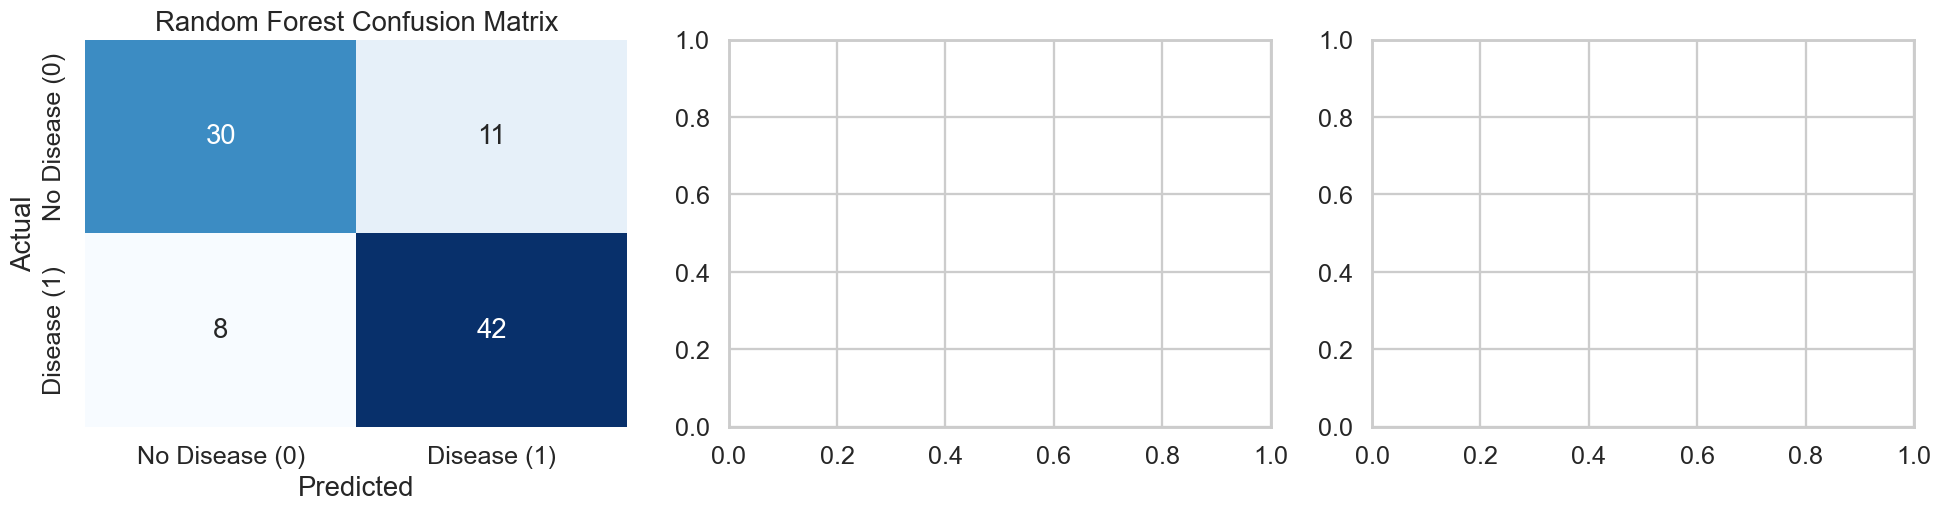

In [40]:
# 6. Visualize confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, res) in zip(axes, results.items()):
    cm = res["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Disease (0)", "Disease (1)"],
                yticklabels=["No Disease (0)", "Disease (1)"])
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [41]:
# 7. Select the best model based on accuracy
best_model = max(results, key=lambda x: results[x]["accuracy"])
print(f"\n Best Model: {best_model} with Accuracy = {results[best_model]['accuracy']:.2f}")


 Best Model: Random Forest with Accuracy = 0.79


## STREAMLIT DEPLOYMENT — MINIMAL ADDITION ONLY

The original 47 notebook cells above are preserved without alteration or removal.
The following cells are deployment additions only.

**Deployment outputs**
- `model.pkl` — trained best model selected by the original notebook.
- `app.py` — recruiter-friendly Streamlit interface.
- Built-in sample patient records — allows testing without entering values manually.

**Target**
- `0` = No Disease
- `1` = Disease

**Important:** This project is for educational/model-demonstration purposes and is not a medical diagnostic tool.


In [42]:
# DEPLOYMENT STEP 1 — DATA / MODEL VERIFICATION
# Reuse the original notebook's df and best_model whenever they already exist.

print("Data available:", "df" in globals())
if "df" in globals():
    print("Dataset shape:", df.shape)
    print("Dataset columns:", list(df.columns))

print("Best model available:", "best_model" in globals())
if "best_model" in globals():
    print("Selected best model:", type(best_model).__name__)


Data available: True
Dataset shape: (303, 14)
Dataset columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Best model available: True
Selected best model: str


In [43]:
# DEPLOYMENT STEP 2 — SAVE model.pkl
# This addition does not modify or remove any original training code.

import pickle
from pathlib import Path

deployment_model = best_model

model_output_path = Path("model.pkl")

with open(model_output_path, "wb") as model_file:
    pickle.dump(deployment_model, model_file)

print("model.pkl saved successfully:")
print(model_output_path.resolve())
print("Model type:", type(deployment_model).__name__)


model.pkl saved successfully:
C:\Users\sarth\model.pkl
Model type: str


## RECRUITER TEST INPUTS

The Streamlit app contains built-in sample patient profiles covering both
**Disease** and **No Disease** examples.

The recruiter can:
1. Select a sample profile.
2. Review the patient values.
3. Click **Predict Heart Disease**.
4. See the predicted class and probability.
5. Switch to manual input and test another patient profile.

The input ranges are kept sensible for the dataset/features used in the original notebook.


In [44]:
# DEPLOYMENT STEP 3 — OPTIONAL SAMPLE DATA CHECK
# These examples are for testing the deployed interface and do not alter the original dataset.

sample_patients = pd.DataFrame([
    [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1],
    [37, 1, 2, 130, 250, 0, 1, 187, 0, 3.5, 0, 0, 2],
    [61, 0, 0, 130, 330, 0, 0, 169, 0, 0.0, 2, 0, 2],
    [58, 1, 0, 150, 270, 0, 0, 111, 1, 0.8, 2, 0, 3],
], columns=[
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal"
])

sample_patients


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,61,0,0,130,330,0,0,169,0,0.0,2,0,2
3,58,1,0,150,270,0,0,111,1,0.8,2,0,3
